# Google Play Store Data Visualization

Phân tích và trực quan hóa dữ liệu ứng dụng Google Play Store

In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Cài đặt style cho các biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Đọc dữ liệu
df = pd.read_csv('i:/My Drive/Bài Tập/AI-FullStack/Module 4/Dataset/googleplaystore_cleaned.csv')

# Hiển thị thông tin cơ bản
print('=' * 60)
print('THÔNG TIN DATASET')
print('=' * 60)
print(f'Số dòng: {df.shape[0]}')
print(f'Số cột: {df.shape[1]}')
print(f'\nCác cột: {df.columns.tolist()}')
print('\n' + '=' * 60)
print('5 DÒNG ĐẦU TIÊN')
print('=' * 60)
df.head()

THÔNG TIN DATASET
Số dòng: 8892
Số cột: 17

Các cột: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Size_MB', 'Installs_Num', 'Price_Num', 'Last_Updated_Date', 'Main_Genre']

5 DÒNG ĐẦU TIÊN


,App,Category,Rating,Reviews,Size,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Installs_Num,Price_Num,Last_Updated_Date,Main_Genre
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0,10000,0.0,2018-01-07,Art & Design
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000,0.0,2018-01-15,Art & Design
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7,5000000,0.0,2018-08-01,Art & Design
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0,50000000,0.0,2018-06-08,Art & Design
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8,100000,0.0,2018-06-20,Art & Design


In [2]:
# Thống kê mô tả
print('=' * 60)
print('THỐNG KÊ MÔ TẢ')
print('=' * 60)
df.describe()

THỐNG KÊ MÔ TẢ


,Rating,Reviews,Size_MB,Installs_Num,Price_Num
count,8892.000000,8.892000e+03,7424.000000,8.892000e+03,8892.000000
mean,4.187877,4.727764e+05,22.747273,1.648965e+07,0.963155
std,0.522377,2.905052e+06,23.435118,8.637600e+07,16.189341
min,1.000000,1.000000e+00,0.008301,1.000000e+00,0.000000
25%,4.000000,1.640000e+02,5.100000,1.000000e+04,0.000000
50%,4.300000,4.714500e+03,14.000000,5.000000e+05,0.000000
75%,4.500000,7.126675e+04,33.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


## 1. Phân Tích Rating (Đánh Giá)

- Phân phối đánh giá ứng dụng
- Trung bình, trung vị, mode rating

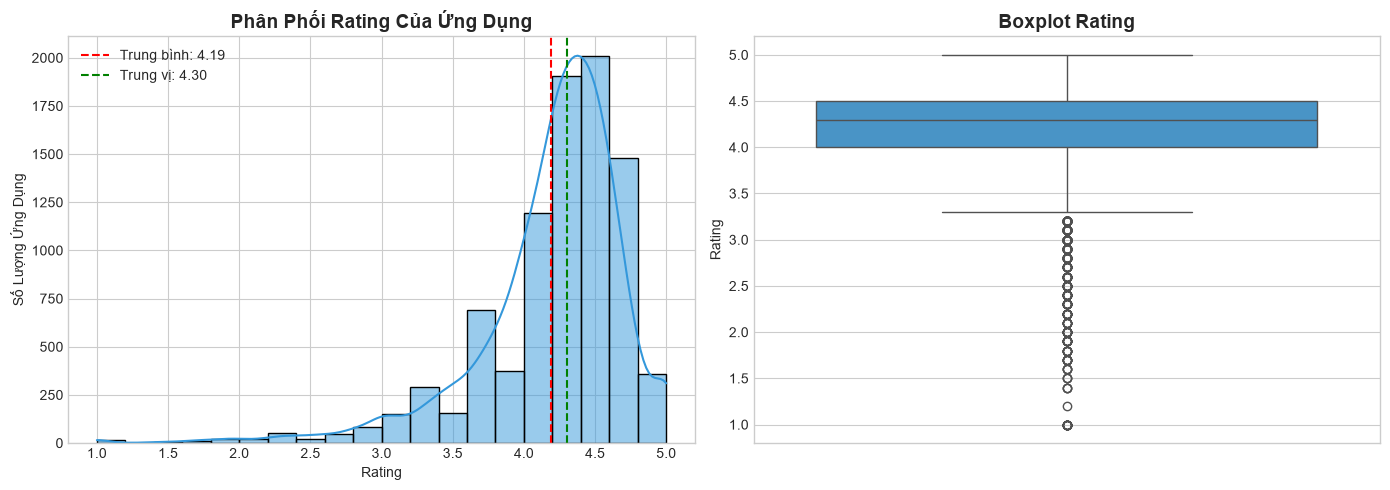


📊 Thống kê Rating:
   - Trung bình: 4.188
   - Trung vị: 4.300
   - Mode: 4.4
   - Min: 1.0, Max: 5.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối Rating
sns.histplot(df['Rating'].dropna(), kde=True, ax=axes[0], color='#3498db', bins=20)
axes[0].set_title('Phân Phối Rating Của Ứng Dụng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Số Lượng Ứng Dụng')
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Trung bình: {df["Rating"].mean():.2f}')
axes[0].axvline(df['Rating'].median(), color='green', linestyle='--', label=f'Trung vị: {df["Rating"].median():.2f}')
axes[0].legend()

# Biểu đồ 2: Boxplot Rating
sns.boxplot(y=df['Rating'].dropna(), ax=axes[1], color='#3498db')
axes[1].set_title('Boxplot Rating', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.savefig('01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Thống kê Rating:')
print(f'   - Trung bình: {df["Rating"].mean():.3f}')
print(f'   - Trung vị: {df["Rating"].median():.3f}')
print(f'   - Mode: {df["Rating"].mode().values[0]:.1f}')
print(f'   - Min: {df["Rating"].min():.1f}, Max: {df["Rating"].max():.1f}')

## 2. Phân Tích Category (Danh Mục)

- Số lượng ứng dụng theo danh mục
- Top 15 danh mục phổ biến nhất

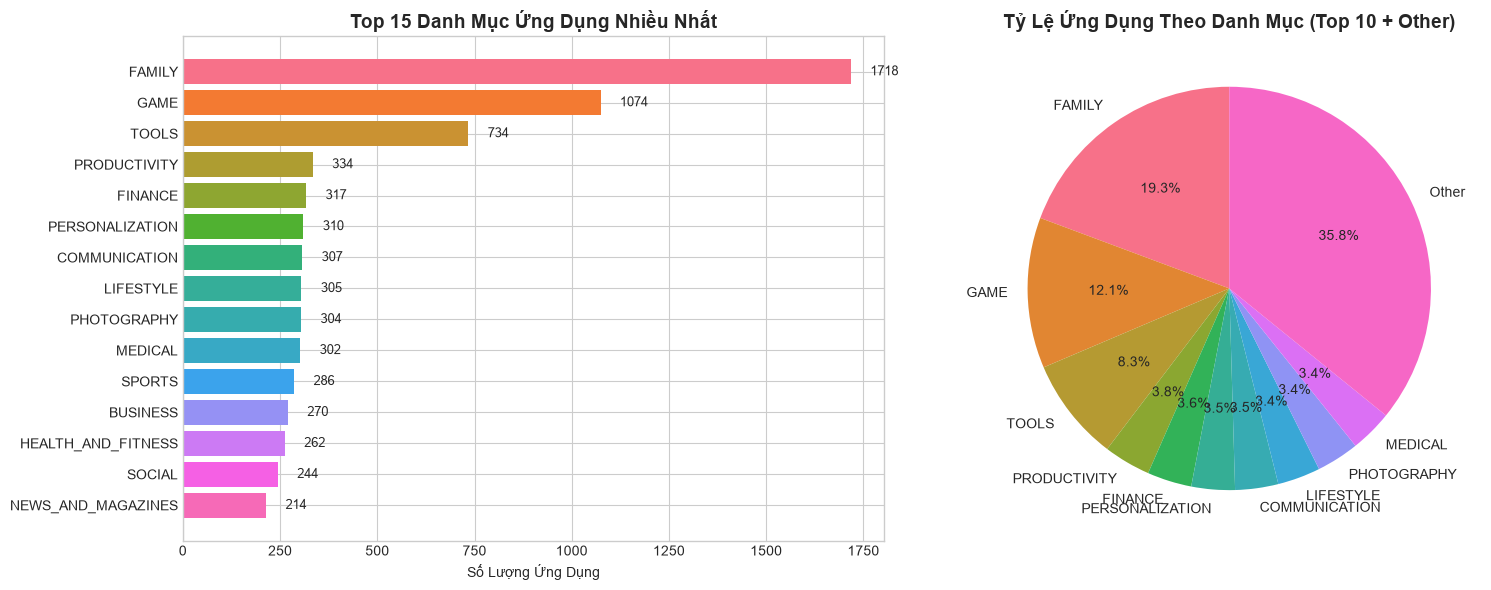


📊 Thống kê Category:
   - Tổng số danh mục: 33
   - Danh mục nhiều nhất: FAMILY (1718 ứng dụng)
   - Danh mục ít nhất: NEWS_AND_MAGAZINES (214 ứng dụng)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đếm số ứng dụng theo category
category_counts = df['Category'].value_counts().head(15)

# Biểu đồ 1: Top 15 Categories (Bar chart)
colors = sns.color_palette('husl', 15)
bars = axes[0].barh(range(len(category_counts)), category_counts.values, color=colors)
axes[0].set_yticks(range(len(category_counts)))
axes[0].set_yticklabels(category_counts.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Số Lượng Ứng Dụng')
axes[0].set_title('Top 15 Danh Mục Ứng Dụng Nhiều Nhất', fontsize=14, fontweight='bold')

# Thêm số liệu trên cột
for i, (bar, count) in enumerate(zip(bars, category_counts.values)):
    axes[0].text(count + 50, i, str(count), va='center', fontsize=9)

# Biểu đồ 2: Pie chart cho Top 10
top10 = df['Category'].value_counts().head(10)
other = df['Category'].value_counts().sum() - top10.sum()
pie_data = pd.concat([top10, pd.Series({'Other': other})])

axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', 
            colors=sns.color_palette('husl', len(pie_data)), startangle=90)
axes[1].set_title('Tỷ Lệ Ứng Dụng Theo Danh Mục (Top 10 + Other)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('02_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Thống kê Category:')
print(f'   - Tổng số danh mục: {df["Category"].nunique()}')
print(f'   - Danh mục nhiều nhất: {category_counts.index[0]} ({category_counts.values[0]} ứng dụng)')
print(f'   - Danh mục ít nhất: {category_counts.index[-1]} ({category_counts.values[-1]} ứng dụng)')

## 3. Phân Tích Type (Free vs Paid)

- Tỷ lệ ứng dụng Free/Paid
- So sánh Rating giữa Free và Paid apps

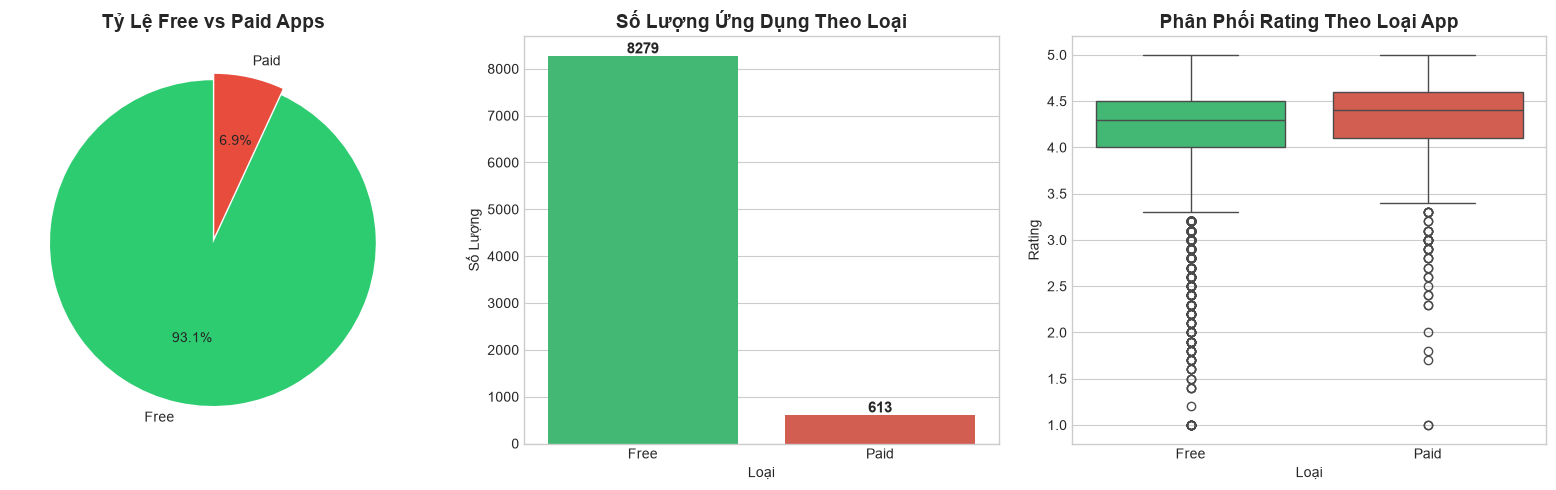


📊 Thống kê Type:
   - Free apps: 8279 (93.1%)
   - Paid apps: 613 (6.9%)
   - Rating TB Free: 4.182
   - Rating TB Paid: 4.262


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Biểu đồ 1: Pie chart Type
type_counts = df['Type'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.02, 0.02], startangle=90)
axes[0].set_title('Tỷ Lệ Free vs Paid Apps', fontsize=14, fontweight='bold')

# Biểu đồ 2: Countplot Type
sns.countplot(x='Type', data=df, ax=axes[1], palette=colors)
axes[1].set_title('Số Lượng Ứng Dụng Theo Loại', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loại')
axes[1].set_ylabel('Số Lượng')
for i, count in enumerate(type_counts.values):
    axes[1].text(i, count + 50, str(count), ha='center', fontsize=11, fontweight='bold')

# Biểu đồ 3: Boxplot Rating theo Type
sns.boxplot(x='Type', y='Rating', data=df, ax=axes[2], palette=colors)
axes[2].set_title('Phân Phối Rating Theo Loại App', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Loại')
axes[2].set_ylabel('Rating')

plt.tight_layout()
plt.savefig('03_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Thống kê Type:')
print(f'   - Free apps: {type_counts.get("Free", 0)} ({type_counts.get("Free", 0)/len(df)*100:.1f}%)')
print(f'   - Paid apps: {type_counts.get("Paid", 0)} ({type_counts.get("Paid", 0)/len(df)*100:.1f}%)')
print(f'   - Rating TB Free: {df[df["Type"]=="Free"]["Rating"].mean():.3f}')
print(f'   - Rating TB Paid: {df[df["Type"]=="Paid"]["Rating"].mean():.3f}')

## 4. Phân Tích Content Rating (Độ Tuổi Nội Dung)

- Phân phối theo nhóm độ tuổi
- Rating trung bình theo từng nhóm độ tuổi

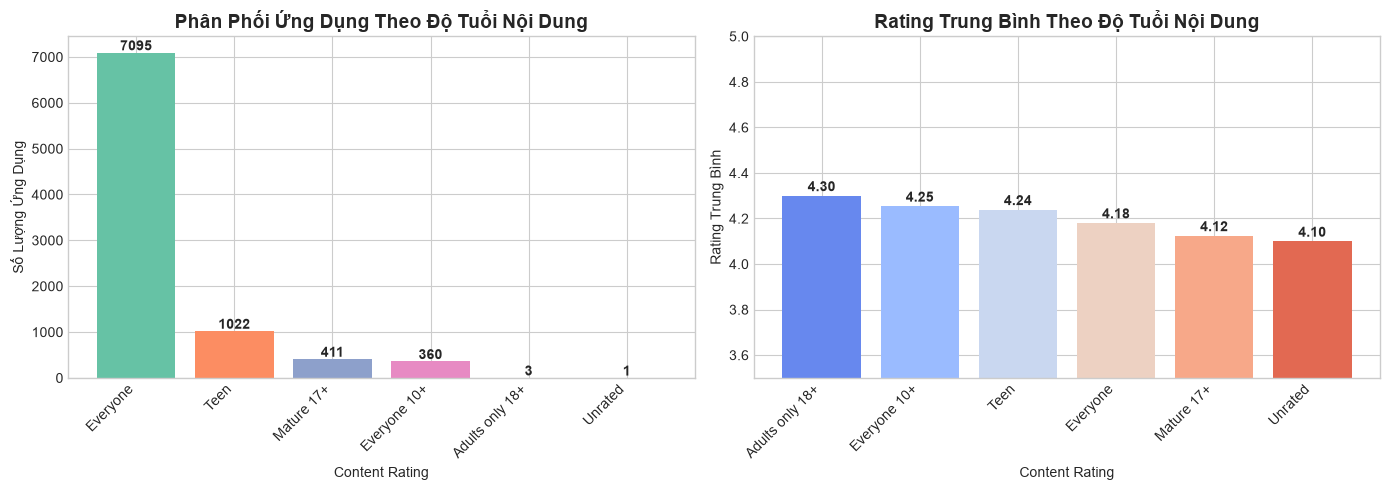


📊 Content Rating Distribution:
   - Everyone: 7095 ứng dụng
   - Teen: 1022 ứng dụng
   - Mature 17+: 411 ứng dụng
   - Everyone 10+: 360 ứng dụng
   - Adults only 18+: 3 ứng dụng
   - Unrated: 1 ứng dụng


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đếm theo Content Rating
content_counts = df['Content Rating'].value_counts()

# Biểu đồ 1: Bar chart
colors = sns.color_palette('Set2', len(content_counts))
bars = axes[0].bar(range(len(content_counts)), content_counts.values, color=colors)
axes[0].set_xticks(range(len(content_counts)))
axes[0].set_xticklabels(content_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Content Rating')
axes[0].set_ylabel('Số Lượng Ứng Dụng')
axes[0].set_title('Phân Phối Ứng Dụng Theo Độ Tuổi Nội Dung', fontsize=14, fontweight='bold')

for bar, count in zip(bars, content_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 50, str(count), 
                ha='center', fontsize=10, fontweight='bold')

# Biểu đồ 2: Rating trung bình theo Content Rating
avg_rating = df.groupby('Content Rating')['Rating'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(range(len(avg_rating)), avg_rating.values, color=sns.color_palette('coolwarm', len(avg_rating)))
axes[1].set_xticks(range(len(avg_rating)))
axes[1].set_xticklabels(avg_rating.index, rotation=45, ha='right')
axes[1].set_xlabel('Content Rating')
axes[1].set_ylabel('Rating Trung Bình')
axes[1].set_title('Rating Trung Bình Theo Độ Tuổi Nội Dung', fontsize=14, fontweight='bold')
axes[1].set_ylim(3.5, 5)

for bar, rating in zip(bars2, avg_rating.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, rating + 0.02, f'{rating:.2f}', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('04_content_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Content Rating Distribution:')
for cr, count in content_counts.items():
    print(f'   - {cr}: {count} ứng dụng')

## 5. Phân Tích Kích Thước (Size)

- Phân phối kích thước ứng dụng (MB)
- So sánh kích thước Free vs Paid

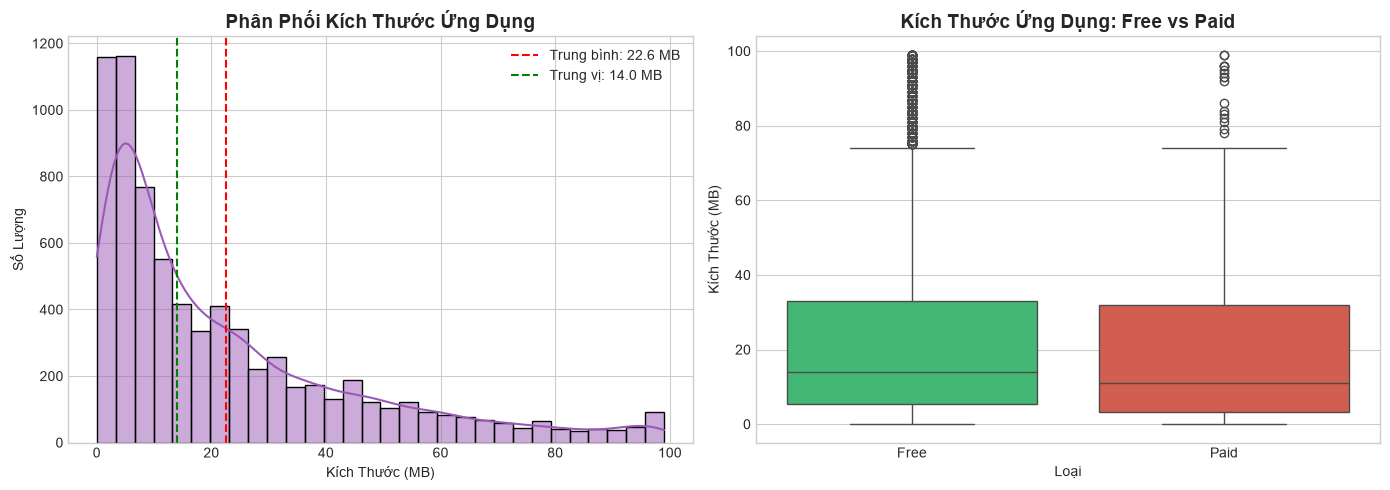


📊 Thống kê Size:
   - Trung bình: 22.58 MB
   - Trung vị: 14.00 MB
   - Min: 0.01 MB, Max: 99.00 MB


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loại bỏ các giá trị null và extreme
size_data = df['Size_MB'].dropna()
size_data = size_data[(size_data > 0) & (size_data < 100)]  # Giới hạn để visualization tốt hơn

# Biểu đồ 1: Histogram kích thước
sns.histplot(size_data, kde=True, ax=axes[0], color='#9b59b6', bins=30)
axes[0].set_title('Phân Phối Kích Thước Ứng Dụng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kích Thước (MB)')
axes[0].set_ylabel('Số Lượng')
axes[0].axvline(size_data.mean(), color='red', linestyle='--', label=f'Trung bình: {size_data.mean():.1f} MB')
axes[0].axvline(size_data.median(), color='green', linestyle='--', label=f'Trung vị: {size_data.median():.1f} MB')
axes[0].legend()

# Biểu đồ 2: Boxplot Size theo Type
df_size = df[df['Size_MB'].notna() & (df['Size_MB'] > 0) & (df['Size_MB'] < 100)]
sns.boxplot(x='Type', y='Size_MB', data=df_size, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Kích Thước Ứng Dụng: Free vs Paid', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loại')
axes[1].set_ylabel('Kích Thước (MB)')

plt.tight_layout()
plt.savefig('05_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Thống kê Size:')
print(f'   - Trung bình: {size_data.mean():.2f} MB')
print(f'   - Trung vị: {size_data.median():.2f} MB')
print(f'   - Min: {size_data.min():.2f} MB, Max: {size_data.max():.2f} MB')

## 6. Phân Tích Số Lượng Cài Đặt (Installs)

- Top 10 ứng dụng được cài đặt nhiều nhất
- Phân phối Installs theo Category

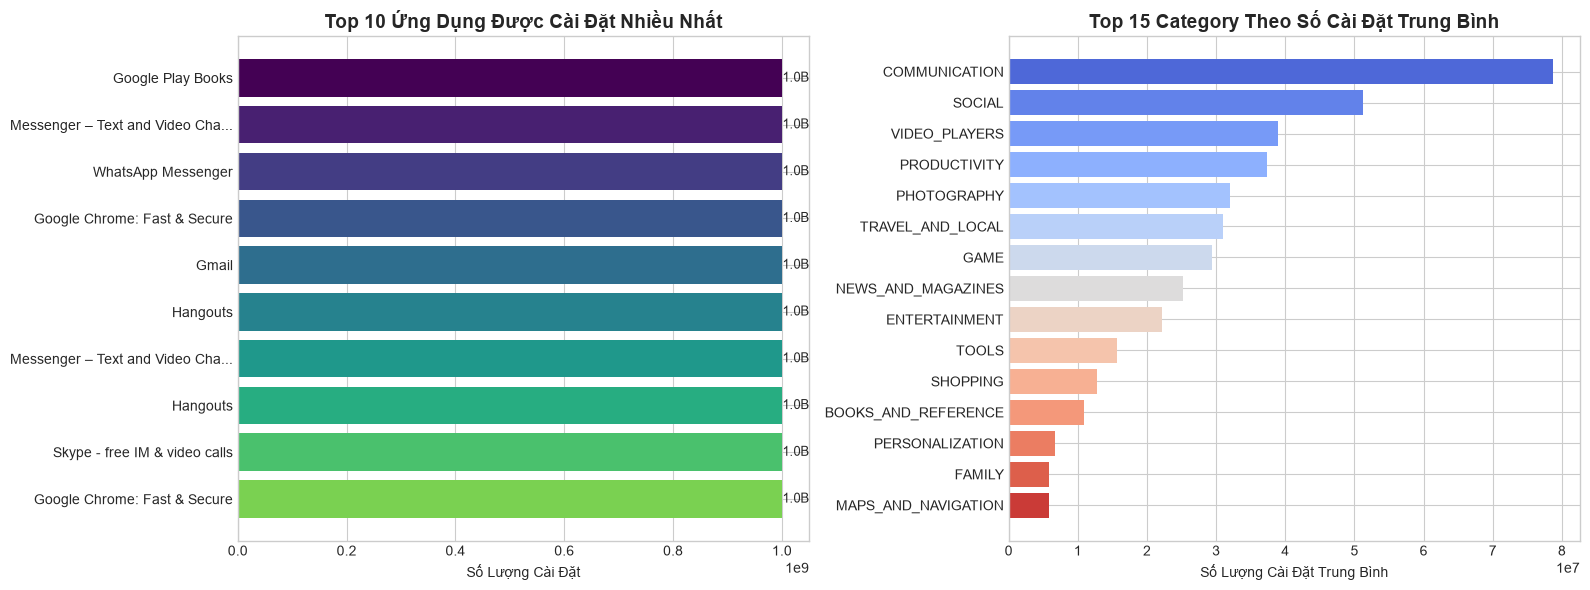


📊 Top 10 Apps by Installs:
   Google Play Books: 1.0B - Rating: 3.9
   Messenger – Text and Video Chat for Free: 1.0B - Rating: 4.0
   WhatsApp Messenger: 1.0B - Rating: 4.4
   Google Chrome: Fast & Secure: 1.0B - Rating: 4.3
   Gmail: 1.0B - Rating: 4.3
   Hangouts: 1.0B - Rating: 4.0
   Messenger – Text and Video Chat for Free: 1.0B - Rating: 4.0
   Hangouts: 1.0B - Rating: 4.0
   Skype - free IM & video calls: 1.0B - Rating: 4.1
   Google Chrome: Fast & Secure: 1.0B - Rating: 4.3


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 apps by installs
top_installs = df.nlargest(10, 'Installs_Num')[['App', 'Category', 'Installs_Num', 'Rating']]

# Biểu đồ 1: Top 10 Apps
colors = plt.cm.viridis(np.linspace(0, 0.8, 10))
bars = axes[0].barh(range(len(top_installs)), top_installs['Installs_Num'].values, color=colors)
axes[0].set_yticks(range(len(top_installs)))
axes[0].set_yticklabels([app[:30] + '...' if len(app) > 30 else app for app in top_installs['App']])
axes[0].invert_yaxis()
axes[0].set_xlabel('Số Lượng Cài Đặt')
axes[0].set_title('Top 10 Ứng Dụng Được Cài Đặt Nhiều Nhất', fontsize=14, fontweight='bold')

# Format số cho cột
def format_number(num):
    if num >= 1e9:
        return f'{num/1e9:.1f}B'
    elif num >= 1e6:
        return f'{num/1e6:.1f}M'
    elif num >= 1e3:
        return f'{num/1e3:.1f}K'
    return str(num)

for i, (bar, count) in enumerate(zip(bars, top_installs['Installs_Num'].values)):
    axes[0].text(count + 1e6, i, format_number(count), va='center', fontsize=9)

# Biểu đồ 2: Installs trung bình theo Category (Top 15)
avg_installs = df.groupby('Category')['Installs_Num'].mean().sort_values(ascending=False).head(15)
colors2 = sns.color_palette('coolwarm', 15)
bars2 = axes[1].barh(range(len(avg_installs)), avg_installs.values, color=colors2)
axes[1].set_yticks(range(len(avg_installs)))
axes[1].set_yticklabels(avg_installs.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Số Lượng Cài Đặt Trung Bình')
axes[1].set_title('Top 15 Category Theo Số Cài Đặt Trung Bình', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('06_installs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Top 10 Apps by Installs:')
for i, row in top_installs.iterrows():
    print(f'   {row["App"][:40]}: {format_number(row["Installs_Num"])} - Rating: {row["Rating"]}')

## 7. Phân Tích Giá (Price)

- Phân phối giá ứng dụng có phí
- Top 10 apps đắt nhất

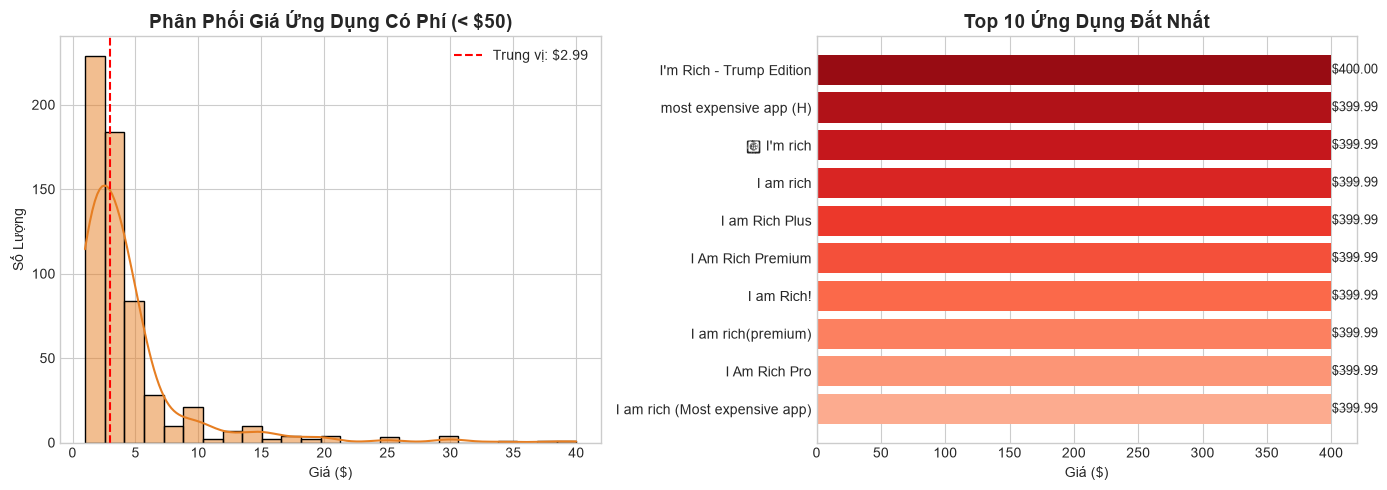


📊 Thống kê Price (Paid Apps):
   - Số lượng paid apps: 613
   - Giá trung bình: $13.97
   - Giá trung vị: $2.99
   - Giá cao nhất: $400.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lọc apps có phí
paid_apps = df[df['Type'] == 'Paid'].copy()

# Biểu đồ 1: Histogram giá (giới hạn < $50)
paid_apps_limited = paid_apps[paid_apps['Price_Num'] < 50]
sns.histplot(paid_apps_limited['Price_Num'], kde=True, ax=axes[0], color='#e67e22', bins=25)
axes[0].set_title('Phân Phối Giá Ứng Dụng Có Phí (< $50)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá ($)')
axes[0].set_ylabel('Số Lượng')
axes[0].axvline(paid_apps_limited['Price_Num'].median(), color='red', linestyle='--', 
                label=f'Trung vị: ${paid_apps_limited["Price_Num"].median():.2f}')
axes[0].legend()

# Biểu đồ 2: Top 10 apps đắt nhất
top_expensive = paid_apps.nlargest(10, 'Price_Num')[['App', 'Category', 'Price_Num', 'Rating']]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, 10))[::-1]
bars = axes[1].barh(range(len(top_expensive)), top_expensive['Price_Num'].values, color=colors)
axes[1].set_yticks(range(len(top_expensive)))
axes[1].set_yticklabels([app[:35] + '...' if len(app) > 35 else app for app in top_expensive['App']])
axes[1].invert_yaxis()
axes[1].set_xlabel('Giá ($)')
axes[1].set_title('Top 10 Ứng Dụng Đắt Nhất', fontsize=14, fontweight='bold')

for bar, price in zip(bars, top_expensive['Price_Num'].values):
    axes[1].text(price + 0.5, bar.get_y() + bar.get_height()/2, f'${price:.2f}', 
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('07_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Thống kê Price (Paid Apps):')
print(f'   - Số lượng paid apps: {len(paid_apps)}')
print(f'   - Giá trung bình: ${paid_apps["Price_Num"].mean():.2f}')
print(f'   - Giá trung vị: ${paid_apps["Price_Num"].median():.2f}')
print(f'   - Giá cao nhất: ${paid_apps["Price_Num"].max():.2f}')

## 8. Ma Trận Tương Quan

- Biểu diễn mối tương quan giữa các biến số

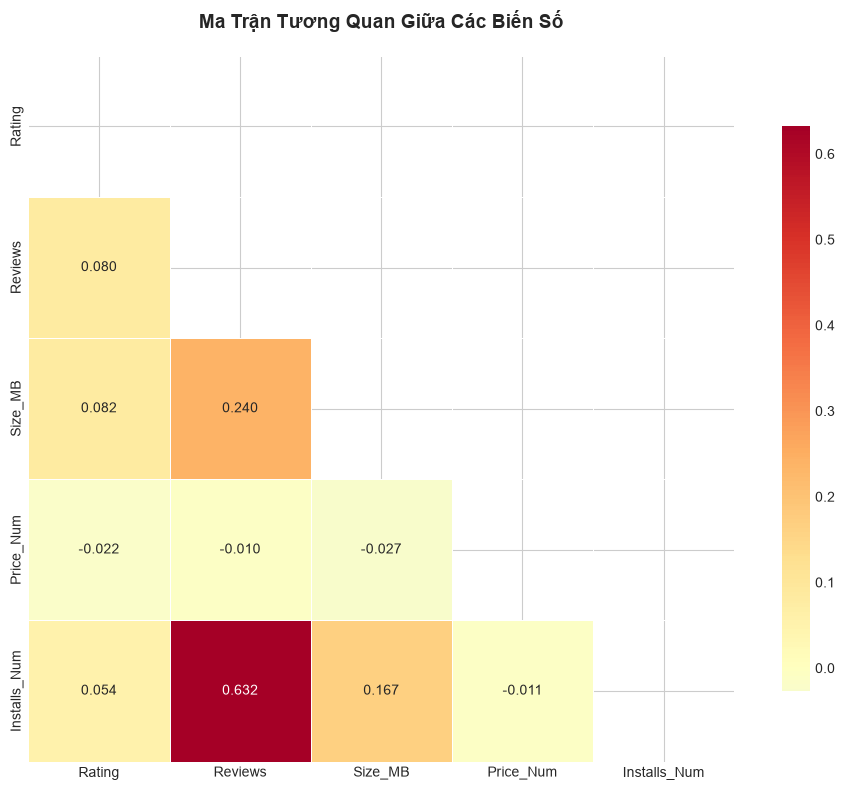


📊 Ma Trận Tương Quan:
              Rating  Reviews  Size_MB  Price_Num  Installs_Num
Rating         1.000    0.080    0.082     -0.022         0.054
Reviews        0.080    1.000    0.240     -0.010         0.632
Size_MB        0.082    0.240    1.000     -0.027         0.167
Price_Num     -0.022   -0.010   -0.027      1.000        -0.011
Installs_Num   0.054    0.632    0.167     -0.011         1.000


In [10]:
# Chọn các cột numeric
numeric_cols = ['Rating', 'Reviews', 'Size_MB', 'Price_Num', 'Installs_Num']
df_numeric = df[numeric_cols].dropna()

# Tính correlation matrix
corr_matrix = df_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Ma Trận Tương Quan Giữa Các Biến Số', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Ma Trận Tương Quan:')
print(corr_matrix.round(3))

## 9. Scatter Plot: Reviews vs Rating

- Mối quan hệ giữa số lượng reviews và rating

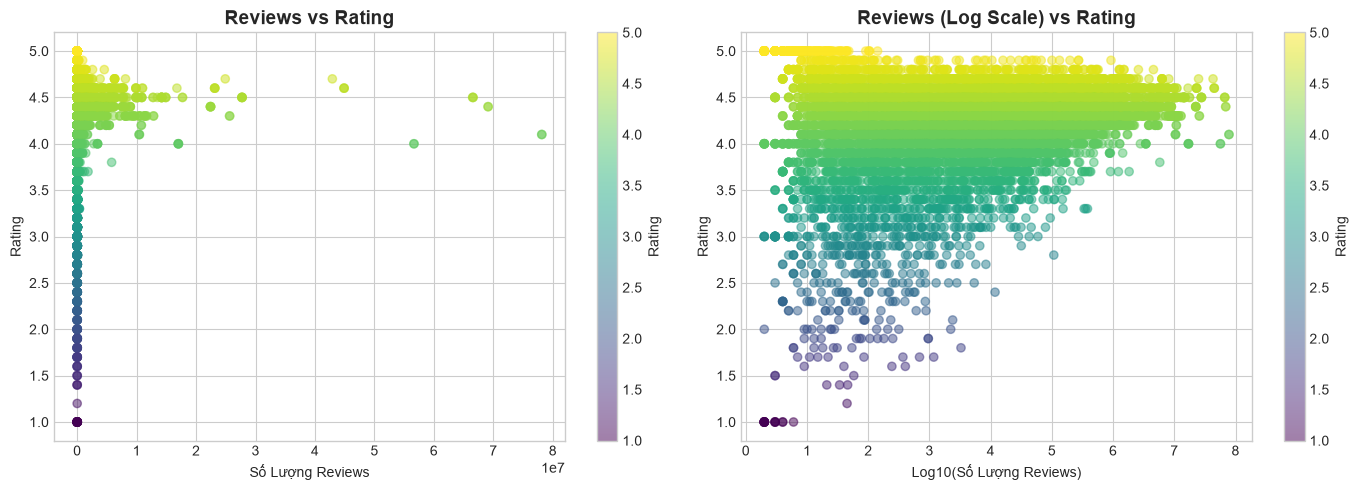


📊 Tương quan Reviews vs Rating: 0.080


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot Reviews vs Rating
df_scatter = df[['Reviews', 'Rating', 'Category']].dropna()
df_scatter = df_scatter[df_scatter['Reviews'] > 0]

# Biểu đồ 1: Scatter plot cơ bản
scatter = axes[0].scatter(df_scatter['Reviews'], df_scatter['Rating'], 
                          alpha=0.5, c=df_scatter['Rating'], cmap='viridis')
axes[0].set_xlabel('Số Lượng Reviews')
axes[0].set_ylabel('Rating')
axes[0].set_title('Reviews vs Rating', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Rating')

# Biểu đồ 2: Log scale để thấy rõ hơn
df_scatter['Reviews_Log'] = np.log10(df_scatter['Reviews'] + 1)
scatter2 = axes[1].scatter(df_scatter['Reviews_Log'], df_scatter['Rating'], 
                           alpha=0.5, c=df_scatter['Rating'], cmap='viridis')
axes[1].set_xlabel('Log10(Số Lượng Reviews)')
axes[1].set_ylabel('Rating')
axes[1].set_title('Reviews (Log Scale) vs Rating', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Rating')

plt.tight_layout()
plt.savefig('09_reviews_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Tương quan Reviews vs Rating: {corr_matrix.loc["Reviews", "Rating"]:.3f}')

## 10. Phân Tích Theo Thể Loại (Genres)

- Top 10 thể loại phổ biến
- Rating trung bình theo thể loại

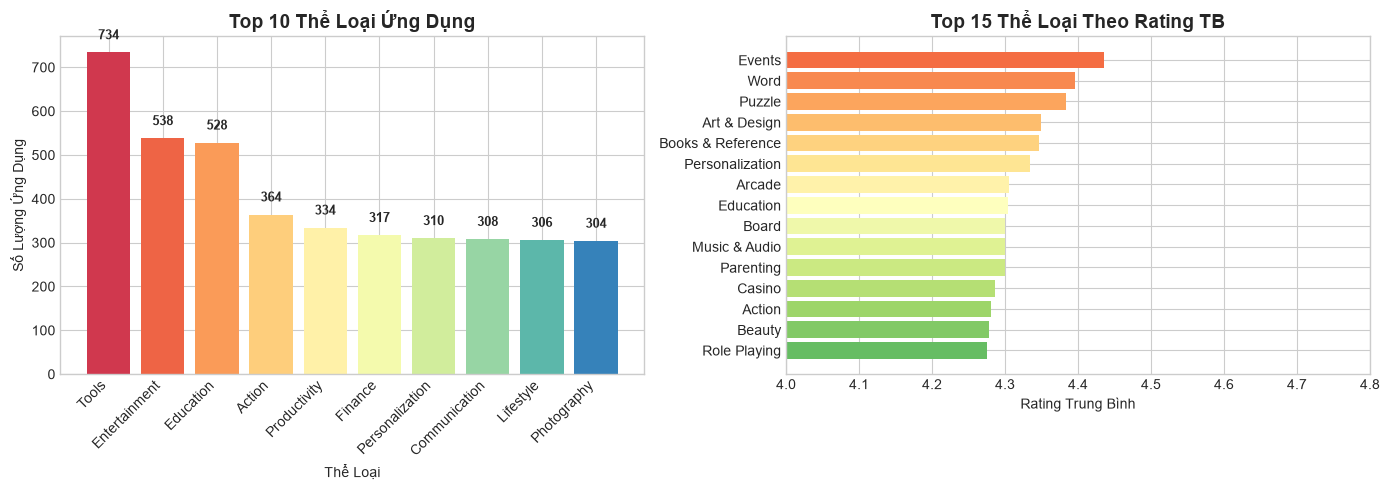

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top Genres
genre_counts = df['Main_Genre'].value_counts().head(10)

# Biểu đồ 1: Top 10 Genres
colors = sns.color_palette('Spectral', 10)
bars = axes[0].bar(range(len(genre_counts)), genre_counts.values, color=colors)
axes[0].set_xticks(range(len(genre_counts)))
axes[0].set_xticklabels(genre_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Thể Loại')
axes[0].set_ylabel('Số Lượng Ứng Dụng')
axes[0].set_title('Top 10 Thể Loại Ứng Dụng', fontsize=14, fontweight='bold')

for bar, count in zip(bars, genre_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 30, str(count), 
                ha='center', fontsize=9, fontweight='bold')

# Biểu đồ 2: Rating trung bình theo Genre
genre_rating = df.groupby('Main_Genre')['Rating'].mean().sort_values(ascending=False)
top_genre_rating = genre_rating.head(15)
colors2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_genre_rating)))
bars2 = axes[1].barh(range(len(top_genre_rating)), top_genre_rating.values, color=colors2)
axes[1].set_yticks(range(len(top_genre_rating)))
axes[1].set_yticklabels(top_genre_rating.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Rating Trung Bình')
axes[1].set_title('Top 15 Thể Loại Theo Rating TB', fontsize=14, fontweight='bold')
axes[1].set_xlim(4, 4.8)

plt.tight_layout()
plt.savefig('10_genres_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Dashboard Tổng Hợp

- Tổng hợp các biểu đồ chính

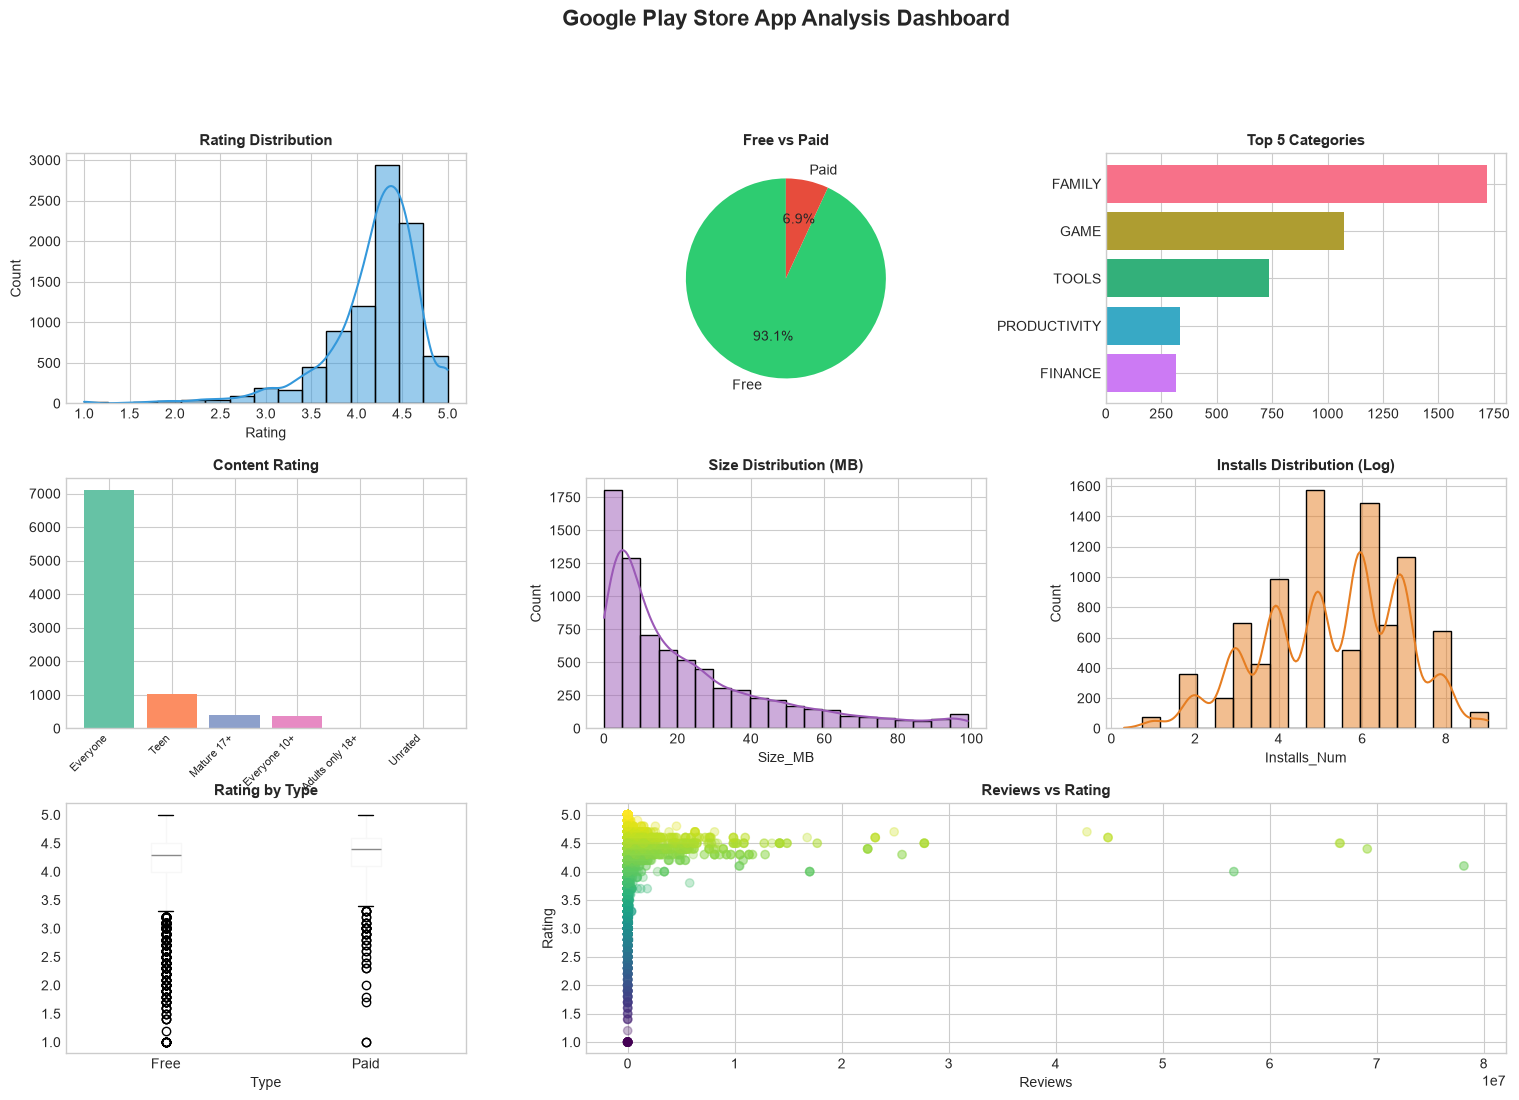

In [13]:
fig = plt.figure(figsize=(18, 12))

# Grid layout
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Rating Distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['Rating'].dropna(), kde=True, ax=ax1, color='#3498db', bins=15)
ax1.set_title('Rating Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('Rating')

# 2. Type Distribution
ax2 = fig.add_subplot(gs[0, 1])
type_counts = df['Type'].value_counts()
ax2.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
        colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Free vs Paid', fontsize=11, fontweight='bold')

# 3. Top Categories
ax3 = fig.add_subplot(gs[0, 2])
top_cat = df['Category'].value_counts().head(5)
ax3.barh(range(len(top_cat)), top_cat.values, color=sns.color_palette('husl', 5))
ax3.set_yticks(range(len(top_cat)))
ax3.set_yticklabels(top_cat.index)
ax3.invert_yaxis()
ax3.set_title('Top 5 Categories', fontsize=11, fontweight='bold')

# 4. Content Rating
ax4 = fig.add_subplot(gs[1, 0])
content_counts = df['Content Rating'].value_counts()
ax4.bar(range(len(content_counts)), content_counts.values, color=sns.color_palette('Set2', len(content_counts)))
ax4.set_xticks(range(len(content_counts)))
ax4.set_xticklabels(content_counts.index, rotation=45, ha='right', fontsize=8)
ax4.set_title('Content Rating', fontsize=11, fontweight='bold')

# 5. Size Distribution
ax5 = fig.add_subplot(gs[1, 1])
size_data = df['Size_MB'].dropna()
size_data = size_data[(size_data > 0) & (size_data < 100)]
sns.histplot(size_data, kde=True, ax=ax5, color='#9b59b6', bins=20)
ax5.set_title('Size Distribution (MB)', fontsize=11, fontweight='bold')

# 6. Installs Distribution (log)
ax6 = fig.add_subplot(gs[1, 2])
installs_log = np.log10(df['Installs_Num'].dropna() + 1)
sns.histplot(installs_log, kde=True, ax=ax6, color='#e67e22', bins=20)
ax6.set_title('Installs Distribution (Log)', fontsize=11, fontweight='bold')

# 7. Rating by Type
ax7 = fig.add_subplot(gs[2, 0])
df.boxplot(column='Rating', by='Type', ax=ax7, grid=False)
ax7.set_title('Rating by Type', fontsize=11, fontweight='bold')
ax7.set_xlabel('Type')
plt.suptitle('')

# 8. Scatter Reviews vs Rating
ax8 = fig.add_subplot(gs[2, 1:])
scatter = ax8.scatter(df['Reviews'], df['Rating'], alpha=0.3, c=df['Rating'], cmap='viridis')
ax8.set_xlabel('Reviews')
ax8.set_ylabel('Rating')
ax8.set_title('Reviews vs Rating', fontsize=11, fontweight='bold')

plt.suptitle('Google Play Store App Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('11_dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Kết Luận và Insights

### Các phát hiện chính từ phân tích dữ liệu:

In [14]:
# Tạo summary
print('=' * 70)
print('📊 TỔNG HỢP PHÂN TÍCH GOOGLE PLAY STORE DATASET')
print('=' * 70)

print('\n1️⃣  TỔNG QUAN DATASET:')
print(f'   • Tổng số ứng dụng: {len(df):,}')
print(f'   • Số danh mục: {df["Category"].nunique()}')
print(f'   • Số thể loại: {df["Main_Genre"].nunique()}')

print('\n2️⃣  RATING ANALYSIS:')
print(f'   • Rating TB: {df["Rating"].mean():.3f}')
print(f'   • Rating phổ biến nhất: {df["Rating"].mode().values[0]}')
print(f'   • Hơn 50% apps có rating >= {df["Rating"].quantile(0.5):.1f}')

print('\n3️⃣  FREE vs PAID:')
type_counts = df['Type'].value_counts()
print(f'   • Free apps: {type_counts.get("Free", 0):,} ({type_counts.get("Free", 0)/len(df)*100:.1f}%)')
print(f'   • Paid apps: {type_counts.get("Paid", 0):,} ({type_counts.get("Paid", 0)/len(df)*100:.1f}%)')
print(f'   • Paid apps có rating TB cao hơn: {df[df["Type"]=="Paid"]["Rating"].mean():.3f} vs {df[df["Type"]=="Free"]["Rating"].mean():.3f}')

print('\n4️⃣  TOP CATEGORIES:')
for i, (cat, count) in enumerate(df['Category'].value_counts().head(5).items()):
    print(f'   {i+1}. {cat}: {count} apps')

print('\n5️⃣  INSTALLS INSIGHTS:')
print(f'   • App được cài đặt nhiều nhất: {df.nlargest(1, "Installs_Num")["App"].values[0][:40]}...')
print(f'   • Với {df.nlargest(1, "Installs_Num")["Installs_Num"].values[0]:,} lượt cài đặt')

print('\n6️⃣  SIZE INSIGHTS:')
size_data = df['Size_MB'].dropna()
print(f'   • Kích thước TB: {size_data.mean():.1f} MB')
print(f'   • Kích thước trung vị: {size_data.median():.1f} MB')

print('\n7️⃣  CORRELATION INSIGHTS:')
print(f'   • Reviews và Installs có tương quan mạnh: {corr_matrix.loc["Reviews", "Installs_Num"]:.3f}')
print(f'   • Rating và Reviews có tương quan yếu: {corr_matrix.loc["Rating", "Reviews"]:.3f}')

print('\n' + '=' * 70)
print('✅ Các file visualization đã được lưu:')
print('   - 01_rating_distribution.png')
print('   - 02_category_distribution.png')
print('   - 03_type_analysis.png')
print('   - 04_content_rating.png')
print('   - 05_size_distribution.png')
print('   - 06_installs_analysis.png')
print('   - 07_price_analysis.png')
print('   - 08_correlation_matrix.png')
print('   - 09_reviews_vs_rating.png')
print('   - 10_genres_analysis.png')
print('   - 11_dashboard_summary.png')
print('=' * 70)

📊 TỔNG HỢP PHÂN TÍCH GOOGLE PLAY STORE DATASET

1️⃣  TỔNG QUAN DATASET:
   • Tổng số ứng dụng: 8,892
   • Số danh mục: 33
   • Số thể loại: 48

2️⃣  RATING ANALYSIS:
   • Rating TB: 4.188
   • Rating phổ biến nhất: 4.4
   • Hơn 50% apps có rating >= 4.3

3️⃣  FREE vs PAID:
   • Free apps: 8,279 (93.1%)
   • Paid apps: 613 (6.9%)
   • Paid apps có rating TB cao hơn: 4.262 vs 4.182

4️⃣  TOP CATEGORIES:
   1. FAMILY: 1718 apps
   2. GAME: 1074 apps
   3. TOOLS: 734 apps
   4. PRODUCTIVITY: 334 apps
   5. FINANCE: 317 apps

5️⃣  INSTALLS INSIGHTS:
   • App được cài đặt nhiều nhất: Google Play Books...
   • Với 1,000,000,000 lượt cài đặt

6️⃣  SIZE INSIGHTS:
   • Kích thước TB: 22.7 MB
   • Kích thước trung vị: 14.0 MB

7️⃣  CORRELATION INSIGHTS:
   • Reviews và Installs có tương quan mạnh: 0.632
   • Rating và Reviews có tương quan yếu: 0.080

✅ Các file visualization đã được lưu:
   - 01_rating_distribution.png
   - 02_category_distribution.png
   - 03_type_analysis.png
   - 04_content_r